In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
import pandas as pd
df=pd.read_excel("Retail_Sales_Dataset.xlsx")


In [38]:
df.head()

,Order ID,Order Date,Customer ID,Customer Name,Age,Gender,Product Category,Product Name,Quantity,Price per Unit,Sales,City,State,Payment Mode
0,ORD00001,2024-10-07,CUST0244,Irya Sekhon,58,Female,Electronics,Mouse,1,199,199,Mumbai,Maharashtra,Cash
1,ORD00002,2024-04-04,CUST0185,Tanmayi Biswas,35,Female,Clothing,Jacket,5,1499,7495,Hyderabad,Telangana,Card
2,ORD00003,2025-09-28,CUST0087,Ansh Deo,53,Male,Grocery,Bread,8,799,6392,Bengaluru,Karnataka,UPI
3,ORD00004,2024-08-20,CUST0086,Vihaan Deep,51,Male,Furniture,Bookshelf,2,1499,2998,Bengaluru,Karnataka,Cash
4,ORD00005,2024-03-27,CUST0110,Joshua Manne,51,Male,Electronics,Mouse,5,199,995,Bengaluru,Karnataka,Card


In [39]:
df.shape

(1000, 14)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Order ID          1000 non-null   str  
 1   Order Date        1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Customer Name     1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Gender            1000 non-null   str  
 6   Product Category  1000 non-null   str  
 7   Product Name      1000 non-null   str  
 8   Quantity          1000 non-null   int64
 9   Price per Unit    1000 non-null   int64
 10  Sales             1000 non-null   int64
 11  City              1000 non-null   str  
 12  State             1000 non-null   str  
 13  Payment Mode      1000 non-null   str  
dtypes: int64(4), str(10)
memory usage: 109.5 KB


In [41]:
df.isnull().sum()

Order ID            0
Order Date          0
Customer ID         0
Customer Name       0
Age                 0
Gender              0
Product Category    0
Product Name        0
Quantity            0
Price per Unit      0
Sales               0
City                0
State               0
Payment Mode        0
dtype: int64

In [42]:
df.duplicated().sum()

np.int64(0)

## Observation
- The dataset contains 1000 rows and 14 columns.
- No missing values found.
- There are no duplicate rows.
- Data types were checked successfully.

In [43]:
df.describe()

,Age,Quantity,Price per Unit,Sales
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,39.147000,4.626000,1534.800000,7144.774000
std,12.832773,2.272287,1547.343734,8593.855374
min,18.000000,1.000000,199.000000,199.000000
25%,28.000000,3.000000,499.000000,1498.500000
50%,39.000000,5.000000,999.000000,3992.000000
75%,51.000000,7.000000,2499.000000,9996.000000
max,60.000000,8.000000,4999.000000,39992.000000


In [44]:
df.mean(numeric_only=True)

Age                 39.147
Quantity             4.626
Price per Unit    1534.800
Sales             7144.774
dtype: float64

In [45]:
df.median(numeric_only=True)

Age                 39.0
Quantity             5.0
Price per Unit     999.0
Sales             3992.0
dtype: float64

In [46]:
df.mode(numeric_only=True)

,Age,Quantity,Price per Unit,Sales
0,23,6,1499,19996


In [47]:
df.std(numeric_only=True)

Age                 12.832773
Quantity             2.272287
Price per Unit    1547.343734
Sales             8593.855374
dtype: float64

## Descriptive Statistics
Observation:

- The average customer age is approximately 40 years.
- The average sales amount is $7145.
- The median quantity sold per transaction is 5 units.
- The standard deviation of sales is 8594.
- This indicates that sales values very significant across transactions.

In [48]:
df["Order Date"]=pd.to_datetime(df["Order Date"])

In [49]:
df["Month"]=df["Order Date"].dt.to_period("M")

In [50]:
monthly_sales=df.groupby("Month")["Sales"].sum()
monthly_sales

Month
2024-01    279173
2024-02    128503
2024-03    345778
2024-04    247633
2024-05    327803
2024-06    273624
2024-07    301175
2024-08    320418
2024-09    368671
2024-10    388876
2024-11    349799
2024-12    284333
2025-01    281517
2025-02    310198
2025-03    311393
2025-04    331482
2025-05    196421
2025-06    300334
2025-07    265710
2025-08    379069
2025-09    392963
2025-10    237640
2025-11    191046
2025-12    331215
Freq: M, Name: Sales, dtype: int64

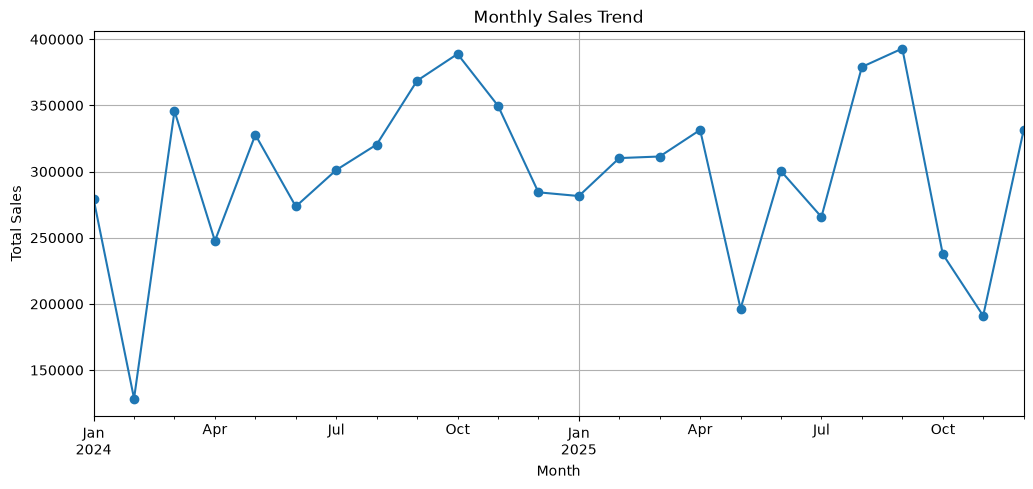

In [51]:
plt.figure(figsize=(12,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

## Monthly Sales Trend
Observation:

- Monthly sales fluctuate over time.
- Some months have significant higher sales than others.
- The line chart helps identify seasonal sales patterns.

In [52]:
df["Quarter"]=df["Order Date"].dt.to_period("Q")

In [53]:
quarterly_sales=df.groupby("Quarter")["Sales"].sum()
quarterly_sales

Quarter
2024Q1     753454
2024Q2     849060
2024Q3     990264
2024Q4    1023008
2025Q1     903108
2025Q2     828237
2025Q3    1037742
2025Q4     759901
Freq: Q-DEC, Name: Sales, dtype: int64

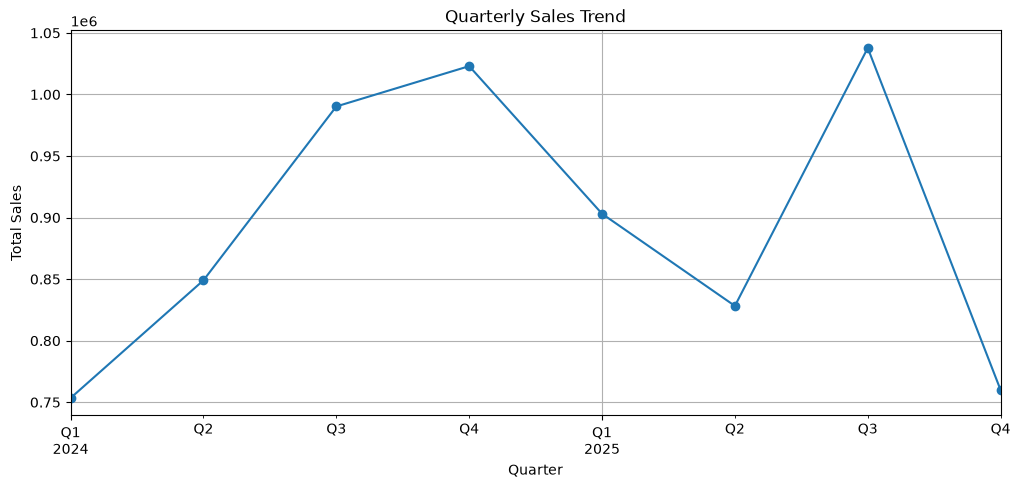

In [54]:
plt.figure(figsize=(12,5))
quarterly_sales.plot(marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

## Quarterly Sales Trend
Observation:

- Sales vary across different quarters.
- Some quarters generated higher sales than others.
- The chart helps identify seasonal business performance.

In [55]:
top_products=df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Jeans         562274
Coffee        558747
Smartphone    542813
Laptop        539577
Chair         516759
Mouse         489555
Shoes         486890
T-Shirt       471882
Jacket        408891
Rice          400550
Name: Sales, dtype: int64

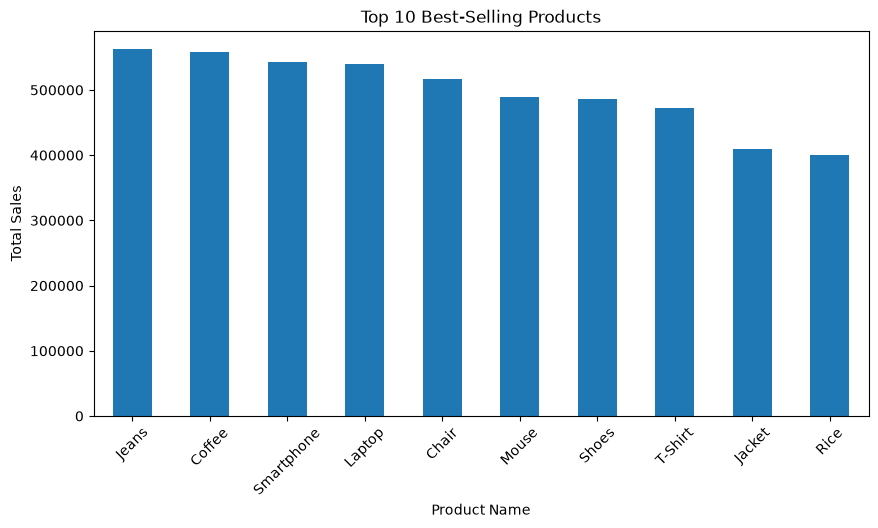

In [56]:
plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## Top 10 best-selling products
Observation:

- The chart shows the top 10 products based on the total sales.
- These products contribute the highest sales.
- The comapany maintain the significant stock of these high-performing products.

In [57]:
category_sales=df.groupby("Product Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Product Category
Electronics    1938804
Clothing       1929937
Grocery        1735048
Furniture      1540985
Name: Sales, dtype: int64

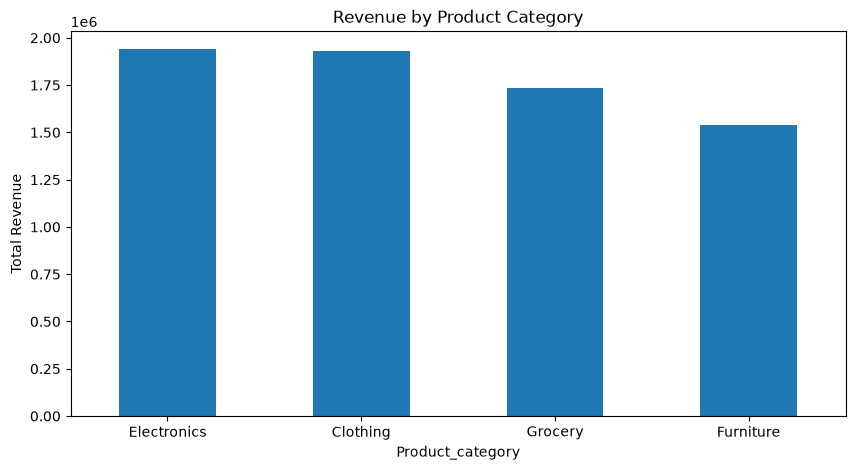

In [58]:
plt.figure(figsize=(10,5))
category_sales.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product_category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()

## Revenue by Product Category
Observation:

- The chart shows the total revenue by each product category.
- Electronics generated the highest revenue.
- Clothing generated revenue close to Electronics.
- Furniture generated the lowest revenue among all the categories.
- The revenue distribution across categories is relatively balanced.

In [59]:
correlation=df[["Age","Price per Unit","Sales","Quantity"]].corr()
correlation

,Age,Price per Unit,Sales,Quantity
Age,1.000000,0.030717,0.038432,0.052418
Price per Unit,0.030717,1.000000,0.819262,0.012751
Sales,0.038432,0.819262,1.000000,0.418764
Quantity,0.052418,0.012751,0.418764,1.000000


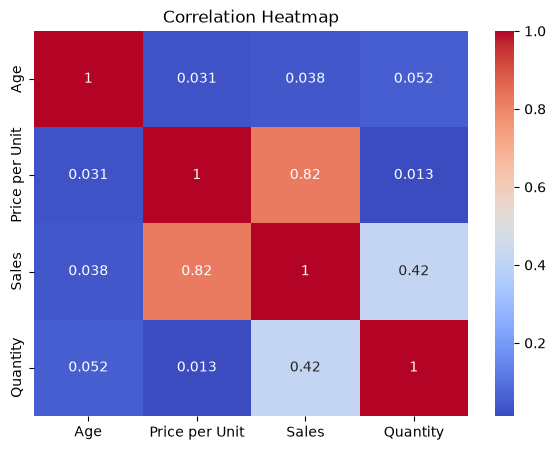

In [60]:
plt.figure(figsize=(7,5))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Correlation Heatmap
- The heatmap shows the relationship between numerical values.
- Price per Unit and Sales have a strong positive correlation(0.82), indicating that higher-priced products generally  generate higher sales.
- Quantity and Sales show a moderate positive correlation(0.42).
- Age has a very weak correlation with Price per Unit, Sales, and Quantity, indicating that customer age has little impact on these variables.


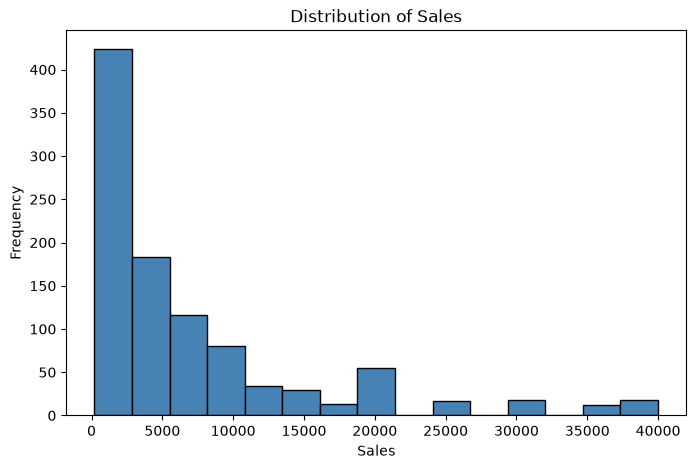

In [61]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"],bins=15,color="steelblue",edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


## Distribution of Sales
Observation:

- Most sales transactions fall in the lower sales range.
- The frequency of transactions decreases as the sales amount increases.
- Only a few transactions have very high sales value.
- This indicates that high-value sales are less common than low-value sales


In [62]:
gender_count=df["Gender"].value_counts()
gender_count

Gender
Female    501
Male      499
Name: count, dtype: int64

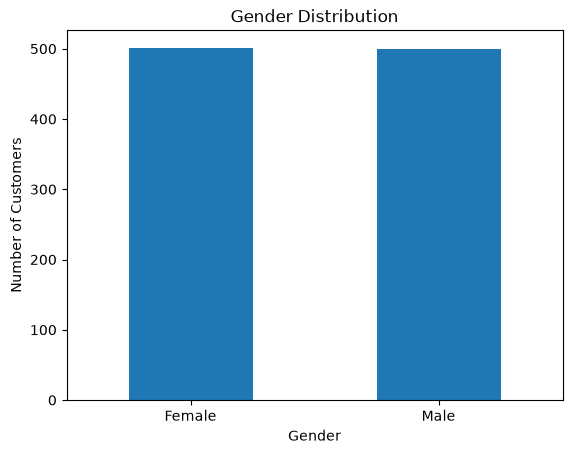

In [63]:
plt.figure("figsize(10,5)")
gender_count.plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

## Gender Distribution
Observation:

- The chart shows the distribution of customers by gender.
- The number of female customers is slightly higher than the number of male customers.
- This indicates that the customer base is fairly balanced, with a small difference between female and  male customers.

## Business Insights

- Electronics is the highest revenue-generating category.
- Most sales transactions are of low value.
- Female customers are slightly more than Male customers.
- The frequency of transactions decreases as the sales amount increases.
- Price per Unit and Sales have a strong positive correlation(0.82)

## Conculsion

This exploratory data analysis provided valuable insights into retail sales performance. Electronics generated the highest revenue, while most sales transactions were of low value. The analysis also showed a strong positive correlation(0.82) between Price per Unit and Sales. These findings can help businesses make better decisions regarding inventory management, product categories, and sales planning.

## Recommendations

- Focus more on high-performing product categories such as Electronics.
- Increase inventory for best-selling products to avoid stock shortages.
- Offers discounts for lower-performing product categories to increase their sales.